## Chest X-ray Disease Classification

<img src="xray-header-image.png" style="padding-top: 50px;width: 87%;left: 0px;margin-left: 0px;margin-right: 0px;">

# Multi-Label Chest X-Ray Disease Classification with PyTorch

### Building and evaluating deep learning models for thoracic disease detection

This notebook develops a PyTorch workflow for multi-label disease classification from chest X-ray images. The focus is on patient-level data leakage, class imbalance, transfer learning, and per-pathology diagnostic evaluation.

**Topics:** Chest X-rays · Multi-label Classification · PyTorch · DenseNet121 · Class Imbalance · Transfer Learning · ROC-AUC · PR-AUC · Sensitivity · Specificity


In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights


In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
from utils.uses import check_for_leakage


## 1. Load the data


In [4]:
train_df = pd.read_csv("data/nih/train-small.csv")
valid_df = pd.read_csv("data/nih/valid-small.csv")
test_df = pd.read_csv("data/nih/test.csv")

print("Initial train size:", len(train_df))
print("Initial valid size:", len(valid_df))
print("Test size:", len(test_df))

train_df.head()


Initial train size: 1000
Initial valid size: 200
Test size: 420


,Image,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,PatientId,Pleural_Thickening,Pneumonia,Pneumothorax
0,00008270_015.png,0,0,0,0,0,0,0,0,0,0,0,8270,0,0,0
1,00029855_001.png,1,0,0,0,1,0,0,0,1,0,0,29855,0,0,0
2,00001297_000.png,0,0,0,0,0,0,0,0,0,0,0,1297,1,0,0
3,00012359_002.png,0,0,0,0,0,0,0,0,0,0,0,12359,0,0,0
4,00017951_001.png,0,0,0,0,0,0,0,0,1,0,0,17951,0,0,0


In [5]:
# Keep disease names separate from batch targets.
# This avoids accidentally overwriting the disease names during training.
disease_names = [
    "Cardiomegaly",
    "Emphysema",
    "Effusion",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Atelectasis",
    "Pneumothorax",
    "Pleural_Thickening",
    "Pneumonia",
    "Fibrosis",
    "Edema",
    "Consolidation",
]

NUM_CLASSES = len(disease_names)
print("Number of pathologies:", NUM_CLASSES)


Number of pathologies: 14


## 2. Check and fix patient-level leakage

The original train/validation files contain overlapping patients.  
The test set is kept untouched. We merge only train + validation and recreate a patient-disjoint split while keeping approximately the original validation proportion.


In [6]:
print("Before re-splitting:")
print("Train / valid leakage:", check_for_leakage(train_df, valid_df, "PatientId"))
print("Train / test leakage :", check_for_leakage(train_df, test_df, "PatientId"))
print("Valid / test leakage :", check_for_leakage(valid_df, test_df, "PatientId"))


Before re-splitting:
Train / valid leakage: True
Train / test leakage : False
Valid / test leakage : False


In [7]:
# Preserve the original validation proportion
valid_ratio = len(valid_df) / (len(train_df) + len(valid_df))

# Merge only train and validation
train_valid_df = pd.concat(
    [train_df, valid_df],
    ignore_index=True
)

# Split unique patients, not images
patients = train_valid_df["PatientId"].unique()

train_patients, valid_patients = train_test_split(
    patients,
    test_size=valid_ratio,
    random_state=SEED
)

# Rebuild patient-disjoint train and validation sets
train_df = train_valid_df[
    train_valid_df["PatientId"].isin(train_patients)
].reset_index(drop=True)

valid_df = train_valid_df[
    train_valid_df["PatientId"].isin(valid_patients)
].reset_index(drop=True)

print(f"Original validation ratio: {valid_ratio:.3f}")
print("New train size:", len(train_df))
print("New valid size:", len(valid_df))


Original validation ratio: 0.167
New train size: 1009
New valid size: 191


In [8]:
print("After re-splitting:")
print("Train / valid leakage:", check_for_leakage(train_df, valid_df, "PatientId"))
print("Train / test leakage :", check_for_leakage(train_df, test_df, "PatientId"))
print("Valid / test leakage :", check_for_leakage(valid_df, test_df, "PatientId"))

assert not check_for_leakage(train_df, valid_df, "PatientId")
assert not check_for_leakage(train_df, test_df, "PatientId")
assert not check_for_leakage(valid_df, test_df, "PatientId")


After re-splitting:
Train / valid leakage: False
Train / test leakage : False
Valid / test leakage : False


## 3. Dataset and preprocessing

We use **sample-wise normalization**, as in the original notebook:

\[
x' = \frac{x - \mu_{\text{image}}}{\sigma_{\text{image}} + \epsilon}
\]

Each X-ray is therefore centered and scaled using its own pixel distribution.

The same preprocessing is applied to **train, validation, and test**, so the only factor changed in the weighted-vs-unweighted experiment is the loss function.


In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir, x_col, y_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.x_col = x_col
        self.y_cols = y_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.image_dir / row[self.x_col]
        image = Image.open(image_path).convert("RGB")

        targets = torch.tensor(
            row[self.y_cols].values.astype("float32"),
            dtype=torch.float32
        )

        if self.transform is not None:
            image = self.transform(image)

        return image, targets


In [10]:
IMAGE_DIR = "data/nih/images-small/"
IMAGE_SIZE = 320
BATCH_SIZE = 8

# Raw transform is used only for visualization.
raw_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

raw_train_dataset = ChestXrayDataset(
    df=train_df,
    image_dir=IMAGE_DIR,
    x_col="Image",
    y_cols=disease_names,
    transform=raw_transform,
)


In [11]:
class SamplewiseNormalize:
    def __call__(self, image):
        # image shape: (C, H, W)
        mean = image.mean()
        std = image.std()

        return (image - mean) / (std + 1e-8)


common_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    SamplewiseNormalize(),
])


In [12]:
train_dataset = ChestXrayDataset(
    train_df, IMAGE_DIR, "Image", disease_names, common_transform
)

valid_dataset = ChestXrayDataset(
    valid_df, IMAGE_DIR, "Image", disease_names, common_transform
)

test_dataset = ChestXrayDataset(
    test_df, IMAGE_DIR, "Image", disease_names, common_transform
)


def make_train_loader(dataset, seed=SEED):
    # A fresh generator is created for each experiment.
    # Using the same seed gives the competing models the same shuffle order.
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator
    )


# Separate loaders for the two loss experiments.
# Both start from the same random shuffle sequence.
train_loader_unweighted = make_train_loader(train_dataset, seed=SEED)
train_loader_weighted = make_train_loader(train_dataset, seed=SEED)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader_unweighted))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))


Train batches: 127
Valid batches: 24
Test batches : 53


## 4. Visualize examples

For visualization, we use the raw resized tensors rather than the normalized model inputs.


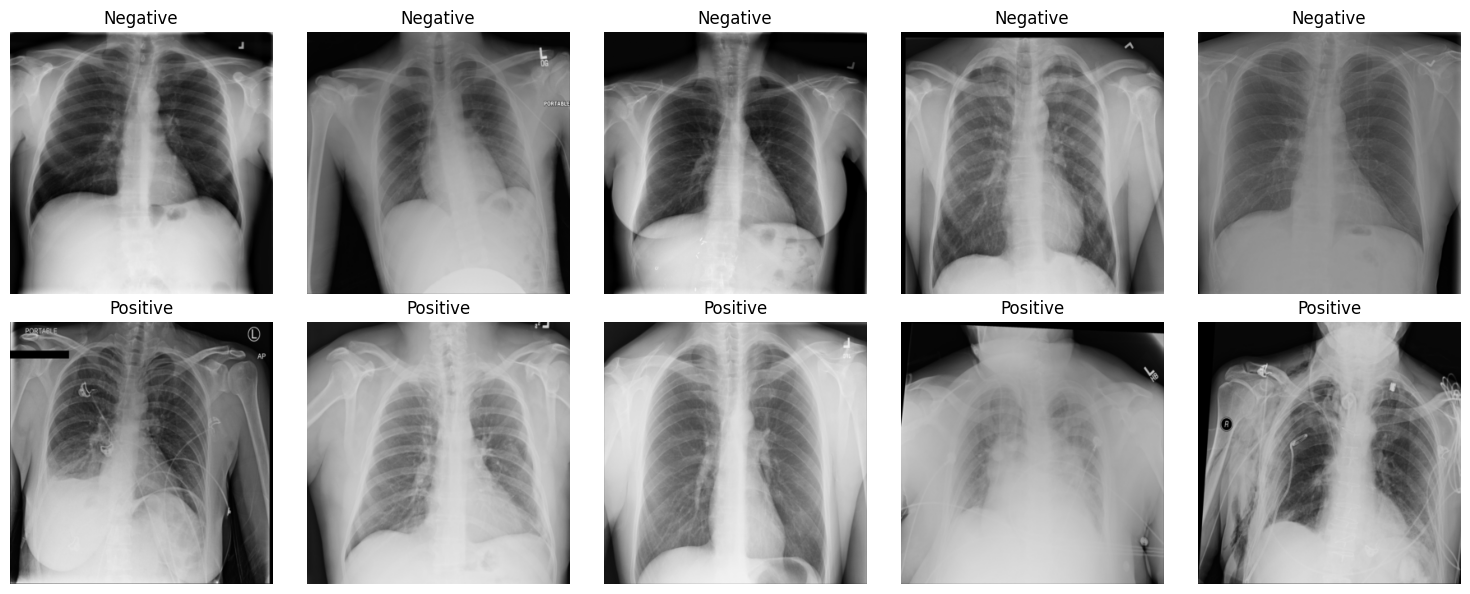

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

negative_count = 0
positive_count = 0

for i in range(len(raw_train_dataset)):
    image, targets = raw_train_dataset[i]

    # Negative: no pathology present
    if targets.sum() == 0 and negative_count < 5:
        axes[0, negative_count].imshow(image.permute(1, 2, 0))
        axes[0, negative_count].axis("off")
        axes[0, negative_count].set_title("Negative")
        negative_count += 1

    # Positive: at least one pathology present
    elif targets.sum() > 0 and positive_count < 5:
        axes[1, positive_count].imshow(image.permute(1, 2, 0))
        axes[1, positive_count].axis("off")
        axes[1, positive_count].set_title("Positive")
        positive_count += 1

    if negative_count == 5 and positive_count == 5:
        break

plt.tight_layout()
plt.show()


## 5. Class imbalance and weighted loss

For each pathology:

\[
\text{pos\_weight}_c = \frac{N_{negative,c}}{N_{positive,c}}
\]

`BCEWithLogitsLoss(pos_weight=...)` increases the penalty for missing rare positive cases.


In [14]:
# train_df[disease_names] shape: (N, 14)
# N = number of training images
# 14 = number of pathologies

n_positive = train_df[disease_names].sum(axis=0).values
# shape: (14,) -> positive count for each pathology

n_negative = len(train_df) - n_positive
# shape: (14,) -> negative count for each pathology

# Avoid division by zero if a pathology has no positive example in training
safe_positive = np.clip(n_positive, a_min=1, a_max=None)

pos_weight = torch.tensor(
    n_negative / safe_positive,
    dtype=torch.float32,
    device=device
)
# shape: torch.Size([14])

imbalance_df = pd.DataFrame({
    "Disease": disease_names,
    "Positive": n_positive.astype(int),
    "Negative": n_negative.astype(int),
    "PosWeight": pos_weight.detach().cpu().numpy()
})

imbalance_df


,Disease,Positive,Negative,PosWeight
0,Cardiomegaly,23,986,42.869564
1,Emphysema,15,994,66.266670
2,Effusion,134,875,6.529851
3,Hernia,2,1007,503.500000
4,Infiltration,174,835,4.798851
5,Mass,46,963,20.934782
6,Nodule,52,957,18.403847
7,Atelectasis,111,898,8.090090
8,Pneumothorax,41,968,23.609756
9,Pleural_Thickening,23,986,42.869564


In [15]:
criterion_unweighted = nn.BCEWithLogitsLoss()

criterion_weighted = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


## 6. Fair comparison: unweighted vs weighted loss

Both models:

- start from **exactly the same random initialization**;
- use the **same patient-level train/validation split**;
- use the **same sample-wise normalization**;
- use the **same optimizer and learning rate**;
- train for the **same number of epochs**;
- see the **same shuffled batch order**.

The only experimental difference is the loss function.


In [16]:
# Create one randomly initialized DenseNet121, then clone it.
# This guarantees identical starting weights.

torch.manual_seed(SEED)

base_scratch_model = densenet121(weights=None)
base_scratch_model.classifier = nn.Linear(
    base_scratch_model.classifier.in_features,
    NUM_CLASSES
)

model_unweighted = copy.deepcopy(base_scratch_model).to(device)
model_weighted = copy.deepcopy(base_scratch_model).to(device)

optimizer_unweighted = torch.optim.Adam(
    model_unweighted.parameters(),
    lr=1e-4
)

optimizer_weighted = torch.optim.Adam(
    model_weighted.parameters(),
    lr=1e-4
)


In [17]:
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss = criterion(logits, targets)

            running_loss += loss.item()

    return running_loss / len(loader)


def train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
):
    history = {
        "train_loss": [],
        "valid_loss": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        valid_loss = evaluate_loss(
            model,
            valid_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Valid Loss: {valid_loss:.4f}"
        )

    return history


In [18]:
NUM_EPOCHS = 10

print("Training with UNWEIGHTED loss")
history_unweighted = train_model(
    model=model_unweighted,
    train_loader=train_loader_unweighted,
    valid_loader=valid_loader,
    criterion=criterion_unweighted,
    optimizer=optimizer_unweighted,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Training with UNWEIGHTED loss
Epoch 01/10 - Train Loss: 0.2872 - Valid Loss: 0.1656
Epoch 02/10 - Train Loss: 0.1674 - Valid Loss: 0.1580
Epoch 03/10 - Train Loss: 0.1597 - Valid Loss: 0.1576
Epoch 04/10 - Train Loss: 0.1554 - Valid Loss: 0.1574
Epoch 05/10 - Train Loss: 0.1505 - Valid Loss: 0.1593
Epoch 06/10 - Train Loss: 0.1467 - Valid Loss: 0.1567
Epoch 07/10 - Train Loss: 0.1471 - Valid Loss: 0.1631
Epoch 08/10 - Train Loss: 0.1354 - Valid Loss: 0.1769
Epoch 09/10 - Train Loss: 0.1336 - Valid Loss: 0.1640
Epoch 10/10 - Train Loss: 0.1277 - Valid Loss: 0.1743


In [19]:
print("Training with WEIGHTED loss")
history_weighted = train_model(
    model=model_weighted,
    train_loader=train_loader_weighted,
    valid_loader=valid_loader,
    criterion=criterion_weighted,
    optimizer=optimizer_weighted,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Training with WEIGHTED loss
Epoch 01/10 - Train Loss: 1.3361 - Valid Loss: 1.4198
Epoch 02/10 - Train Loss: 1.2608 - Valid Loss: 1.3581
Epoch 03/10 - Train Loss: 1.2021 - Valid Loss: 1.4576
Epoch 04/10 - Train Loss: 1.1724 - Valid Loss: 1.3849
Epoch 05/10 - Train Loss: 1.1234 - Valid Loss: 1.4914
Epoch 06/10 - Train Loss: 1.1056 - Valid Loss: 1.4680
Epoch 07/10 - Train Loss: 1.1135 - Valid Loss: 1.4475
Epoch 08/10 - Train Loss: 1.0094 - Valid Loss: 1.5674
Epoch 09/10 - Train Loss: 0.9966 - Valid Loss: 1.4695
Epoch 10/10 - Train Loss: 1.0245 - Valid Loss: 1.6707


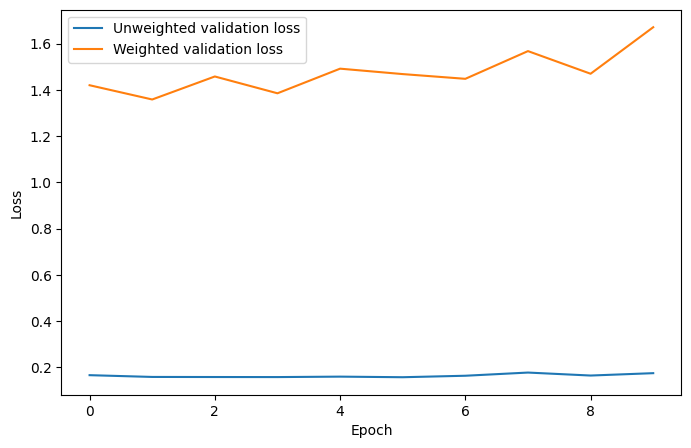

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_unweighted["valid_loss"],
    label="Unweighted validation loss"
)

plt.plot(
    history_weighted["valid_loss"],
    label="Weighted validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Important:
# The absolute values of weighted and unweighted loss are not directly comparable
# because they represent different objective functions.


## 7. Prediction and per-pathology evaluation

ROC-AUC and PR-AUC do not require a classification threshold.  
Sensitivity and specificity below use a default threshold of 0.5.

For very rare diseases, the validation split may contain no positive example.  
In that case ROC-AUC or PR-AUC is reported as `NaN` rather than crashing.


In [21]:
def get_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)

    return y_true, y_prob


In [22]:
def evaluate_multilabel(y_true, y_prob, disease_names, threshold=0.5):
    results = []

    for i, disease in enumerate(disease_names):
        y_true_i = y_true[:, i]
        y_prob_i = y_prob[:, i]

        n_pos = int(y_true_i.sum())
        n_neg = int(len(y_true_i) - n_pos)

        # ROC-AUC requires both classes to be present
        if np.unique(y_true_i).size == 2:
            roc_auc = roc_auc_score(y_true_i, y_prob_i)
        else:
            roc_auc = np.nan

        # PR-AUC requires at least one positive example
        if n_pos > 0:
            pr_auc = average_precision_score(y_true_i, y_prob_i)
        else:
            pr_auc = np.nan

        y_pred_i = (y_prob_i >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true_i,
            y_pred_i,
            labels=[0, 1]
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results.append({
            "Disease": disease,
            "N_Pos": n_pos,
            "N_Neg": n_neg,
            "ROC_AUC": roc_auc,
            "PR_AUC": pr_auc,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
        })

    return pd.DataFrame(results)


In [23]:
# Validation predictions
y_true_unweighted, y_prob_unweighted = get_predictions(
    model_unweighted,
    valid_loader,
    device
)

y_true_weighted, y_prob_weighted = get_predictions(
    model_weighted,
    valid_loader,
    device
)

results_unweighted = evaluate_multilabel(
    y_true_unweighted,
    y_prob_unweighted,
    disease_names
).add_suffix("_Unweighted").rename(
    columns={"Disease_Unweighted": "Disease"}
)

results_weighted = evaluate_multilabel(
    y_true_weighted,
    y_prob_weighted,
    disease_names
).add_suffix("_Weighted").rename(
    columns={"Disease_Weighted": "Disease"}
)

comparison_df = results_unweighted.merge(
    results_weighted,
    on="Disease"
)

comparison_df


,Disease,N_Pos_Unweighted,N_Neg_Unweighted,ROC_AUC_Unweighted,PR_AUC_Unweighted,Sensitivity_Unweighted,Specificity_Unweighted,N_Pos_Weighted,N_Neg_Weighted,ROC_AUC_Weighted,PR_AUC_Weighted,Sensitivity_Weighted,Specificity_Weighted
0,Cardiomegaly,1,190,0.452632,0.009524,0.000000,1.000000,1,190,0.094737,0.005780,0.000000,0.810526
1,Emphysema,1,190,0.552632,0.011628,0.000000,1.000000,1,190,0.221053,0.006711,0.000000,0.778947
2,Effusion,21,170,0.731092,0.216951,0.047619,0.958824,21,170,0.563866,0.205703,0.333333,0.723529
3,Hernia,1,190,0.868421,0.038462,0.000000,1.000000,1,190,0.742105,0.020000,1.000000,0.742105
4,Infiltration,30,161,0.614286,0.245644,0.066667,0.968944,30,161,0.631677,0.333035,0.500000,0.726708
5,Mass,8,183,0.635246,0.074277,0.000000,1.000000,8,183,0.529372,0.111284,0.500000,0.672131
6,Nodule,13,178,0.484443,0.069038,0.000000,0.988764,13,178,0.486171,0.067440,0.230769,0.651685
7,Atelectasis,14,177,0.655367,0.113726,0.000000,1.000000,14,177,0.564972,0.093912,0.285714,0.711864
8,Pneumothorax,7,184,0.669255,0.164763,0.000000,1.000000,7,184,0.514752,0.227683,0.285714,0.750000
9,Pleural_Thickening,4,187,0.500000,0.026400,0.000000,1.000000,4,187,0.407754,0.020944,0.000000,0.684492


In [24]:
summary = pd.DataFrame({
    "Model": ["Unweighted", "Weighted"],
    "Macro ROC-AUC": [
        np.nanmean(comparison_df["ROC_AUC_Unweighted"]),
        np.nanmean(comparison_df["ROC_AUC_Weighted"]),
    ],
    "Macro PR-AUC": [
        np.nanmean(comparison_df["PR_AUC_Unweighted"]),
        np.nanmean(comparison_df["PR_AUC_Weighted"]),
    ],
    "Mean Sensitivity": [
        np.nanmean(comparison_df["Sensitivity_Unweighted"]),
        np.nanmean(comparison_df["Sensitivity_Weighted"]),
    ],
    "Mean Specificity": [
        np.nanmean(comparison_df["Specificity_Unweighted"]),
        np.nanmean(comparison_df["Specificity_Weighted"]),
    ],
})

summary


,Model,Macro ROC-AUC,Macro PR-AUC,Mean Sensitivity,Mean Specificity
0,Unweighted,0.651037,0.097852,0.008163,0.994038
1,Weighted,0.501318,0.091084,0.303728,0.755271


### Interpretation

Do not choose between weighted and unweighted loss from training loss alone.

For an imbalanced medical classification problem, inspect especially:

- **PR-AUC**, because positive findings can be rare.
- **Sensitivity**, because a weighted loss often increases detection of positive cases.
- **Specificity**, because increased sensitivity may come with more false positives.
- **Per-pathology results**, rather than only a single macro average.

The validation set is used for model/loss selection. The test set should remain untouched until the final model choice.


### Experimental control

For the weighted-vs-unweighted comparison, only one factor changes: `pos_weight`.
If performance differs, the difference is therefore not confounded by preprocessing,
initial weights, number of epochs, optimizer settings, or batch order.


## 8. Transfer learning with ImageNet-pretrained DenseNet121

This is a separate experiment from the weighted-vs-unweighted comparison above.


In [25]:
pretrained_model = densenet121(
    weights=DenseNet121_Weights.DEFAULT
)

pretrained_model.classifier = nn.Linear(
    pretrained_model.classifier.in_features,
    NUM_CLASSES
)

pretrained_model = pretrained_model.to(device)

pretrained_optimizer = torch.optim.Adam(
    pretrained_model.parameters(),
    lr=1e-4
)


In [26]:
# Separate transfer-learning experiment.
# A fresh loader is used so its shuffle state does not depend on previous experiments.

train_loader_pretrained = make_train_loader(train_dataset, seed=SEED)

history_pretrained = train_model(
    model=pretrained_model,
    train_loader=train_loader_pretrained,
    valid_loader=valid_loader,
    criterion=criterion_unweighted,
    optimizer=pretrained_optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch 01/10 - Train Loss: 0.2582 - Valid Loss: 0.1573
Epoch 02/10 - Train Loss: 0.1329 - Valid Loss: 0.1536
Epoch 03/10 - Train Loss: 0.1045 - Valid Loss: 0.1588
Epoch 04/10 - Train Loss: 0.0755 - Valid Loss: 0.1576
Epoch 05/10 - Train Loss: 0.0548 - Valid Loss: 0.1636
Epoch 06/10 - Train Loss: 0.0403 - Valid Loss: 0.1668
Epoch 07/10 - Train Loss: 0.0411 - Valid Loss: 0.1751
Epoch 08/10 - Train Loss: 0.0274 - Valid Loss: 0.1905
Epoch 09/10 - Train Loss: 0.0250 - Valid Loss: 0.1771
Epoch 10/10 - Train Loss: 0.0224 - Valid Loss: 0.1982


In [27]:
y_true_pretrained, y_prob_pretrained = get_predictions(
    pretrained_model,
    valid_loader,
    device
)

results_pretrained = evaluate_multilabel(
    y_true_pretrained,
    y_prob_pretrained,
    disease_names
)

results_pretrained


,Disease,N_Pos,N_Neg,ROC_AUC,PR_AUC,Sensitivity,Specificity
0,Cardiomegaly,1,190,0.173684,0.006329,0.000000,1.000000
1,Emphysema,1,190,0.815789,0.027778,0.000000,1.000000
2,Effusion,21,170,0.756863,0.316592,0.000000,0.982353
3,Hernia,1,190,0.721053,0.018519,0.000000,1.000000
4,Infiltration,30,161,0.566874,0.266426,0.066667,0.975155
5,Mass,8,183,0.687842,0.110583,0.000000,1.000000
6,Nodule,13,178,0.675454,0.146743,0.000000,0.994382
7,Atelectasis,14,177,0.679984,0.154742,0.000000,0.960452
8,Pneumothorax,7,184,0.680901,0.246555,0.142857,1.000000
9,Pleural_Thickening,4,187,0.664439,0.037149,0.000000,1.000000


In [28]:
from sklearn.metrics import f1_score

def find_best_thresholds_f1(
    y_true,
    y_prob,
    disease_names,
    thresholds=np.arange(0.01, 1.00, 0.01)
):
    """
    Find one optimal threshold per disease using the validation set.
    The threshold maximizes the F1-score for each pathology.
    """

    best_thresholds = {}
    rows = []

    for i, disease in enumerate(disease_names):
        y_true_i = y_true[:, i]
        y_prob_i = y_prob[:, i]

        # If validation contains no positive cases,
        # threshold optimization is not meaningful.
        if np.sum(y_true_i) == 0:
            best_thresholds[disease] = 0.5

            rows.append({
                "Disease": disease,
                "Best_Threshold": 0.5,
                "Best_F1": np.nan,
                "N_Pos": 0
            })
            continue

        best_threshold = 0.5
        best_f1 = -1

        for threshold in thresholds:
            y_pred_i = (y_prob_i >= threshold).astype(int)

            score = f1_score(
                y_true_i,
                y_pred_i,
                zero_division=0
            )

            if score > best_f1:
                best_f1 = score
                best_threshold = threshold

        best_thresholds[disease] = best_threshold

        rows.append({
            "Disease": disease,
            "Best_Threshold": best_threshold,
            "Best_F1": best_f1,
            "N_Pos": int(np.sum(y_true_i))
        })

    threshold_df = pd.DataFrame(rows)

    return best_thresholds, threshold_df

In [29]:
best_thresholds, threshold_df = find_best_thresholds_f1(
    y_true_pretrained,
    y_prob_pretrained,
    disease_names
)

threshold_df

,Disease,Best_Threshold,Best_F1,N_Pos
0,Cardiomegaly,0.01,0.000000,1
1,Emphysema,0.01,0.000000,1
2,Effusion,0.04,0.408163,21
3,Hernia,0.01,0.000000,1
4,Infiltration,0.08,0.338983,30
5,Mass,0.10,0.181818,8
6,Nodule,0.07,0.222222,13
7,Atelectasis,0.18,0.312500,14
8,Pneumothorax,0.05,0.266667,7
9,Pleural_Thickening,0.01,0.027397,4


In [30]:
def evaluate_multilabel_custom_thresholds(
    y_true,
    y_prob,
    disease_names,
    thresholds
):
    results = []

    for i, disease in enumerate(disease_names):
        y_true_i = y_true[:, i]
        y_prob_i = y_prob[:, i]

        threshold = thresholds[disease]

        n_pos = int(y_true_i.sum())
        n_neg = int(len(y_true_i) - n_pos)

        if np.unique(y_true_i).size == 2:
            roc_auc = roc_auc_score(y_true_i, y_prob_i)
        else:
            roc_auc = np.nan

        if n_pos > 0:
            pr_auc = average_precision_score(
                y_true_i,
                y_prob_i
            )
        else:
            pr_auc = np.nan

        y_pred_i = (
            y_prob_i >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true_i,
            y_pred_i,
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        f1 = f1_score(
            y_true_i,
            y_pred_i,
            zero_division=0
        )

        results.append({
            "Disease": disease,
            "Threshold": threshold,
            "N_Pos": n_pos,
            "N_Neg": n_neg,
            "ROC_AUC": roc_auc,
            "PR_AUC": pr_auc,
            "F1": f1,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
        })

    return pd.DataFrame(results)

In [31]:
results_pretrained_tuned = evaluate_multilabel_custom_thresholds(
    y_true_pretrained,
    y_prob_pretrained,
    disease_names,
    best_thresholds
)

results_pretrained_tuned

,Disease,Threshold,N_Pos,N_Neg,ROC_AUC,PR_AUC,F1,Sensitivity,Specificity
0,Cardiomegaly,0.01,1,190,0.173684,0.006329,0.000000,0.000000,0.721053
1,Emphysema,0.01,1,190,0.815789,0.027778,0.000000,0.000000,0.847368
2,Effusion,0.04,21,170,0.756863,0.316592,0.408163,0.476190,0.894118
3,Hernia,0.01,1,190,0.721053,0.018519,0.000000,0.000000,1.000000
4,Infiltration,0.08,30,161,0.566874,0.266426,0.338983,0.333333,0.881988
5,Mass,0.10,8,183,0.687842,0.110583,0.181818,0.125000,0.989071
6,Nodule,0.07,13,178,0.675454,0.146743,0.222222,0.153846,0.983146
7,Atelectasis,0.18,14,177,0.679984,0.154742,0.312500,0.357143,0.926554
8,Pneumothorax,0.05,7,184,0.680901,0.246555,0.266667,0.285714,0.967391
9,Pleural_Thickening,0.01,4,187,0.664439,0.037149,0.027397,0.250000,0.636364


In [32]:
results_pretrained_default = evaluate_multilabel(
    y_true_pretrained,
    y_prob_pretrained,
    disease_names,
    threshold=0.5
)

threshold_comparison = pd.DataFrame({
    "Strategy": [
        "Threshold = 0.5",
        "Per-disease tuned threshold"
    ],

    "Macro ROC-AUC": [
        np.nanmean(
            results_pretrained_default["ROC_AUC"]
        ),
        np.nanmean(
            results_pretrained_tuned["ROC_AUC"]
        )
    ],

    "Macro PR-AUC": [
        np.nanmean(
            results_pretrained_default["PR_AUC"]
        ),
        np.nanmean(
            results_pretrained_tuned["PR_AUC"]
        )
    ],

    "Mean F1": [
        np.nanmean([
            f1_score(
                y_true_pretrained[:, i],
                (
                    y_prob_pretrained[:, i] >= 0.5
                ).astype(int),
                zero_division=0
            )
            for i in range(NUM_CLASSES)
        ]),
        np.nanmean(
            results_pretrained_tuned["F1"]
        )
    ],

    "Mean Sensitivity": [
        np.nanmean(
            results_pretrained_default["Sensitivity"]
        ),
        np.nanmean(
            results_pretrained_tuned["Sensitivity"]
        )
    ],

    "Mean Specificity": [
        np.nanmean(
            results_pretrained_default["Specificity"]
        ),
        np.nanmean(
            results_pretrained_tuned["Specificity"]
        )
    ]
})

threshold_comparison

,Strategy,Macro ROC-AUC,Macro PR-AUC,Mean F1,Mean Sensitivity,Mean Specificity
0,Threshold = 0.5,0.665191,0.142562,0.025794,0.014966,0.993739
1,Per-disease tuned threshold,0.665191,0.142562,0.197549,0.226040,0.904702


## 9. Final test evaluation

Only run this section after choosing the final model and training strategy from validation results.



In [33]:
# Final model selected from validation results
final_model = pretrained_model

# Get predictions on the untouched test set
y_true_test, y_prob_test = get_predictions(
    final_model,
    test_loader,
    device
)

# ---------------------------------------------------------
# 9.1 Standard evaluation with threshold = 0.5
# ---------------------------------------------------------

test_results_default = evaluate_multilabel(
    y_true_test,
    y_prob_test,
    disease_names,
    threshold=0.5
)

print("Test performance with default threshold = 0.5")
display(test_results_default)

Test performance with default threshold = 0.5


,Disease,N_Pos,N_Neg,ROC_AUC,PR_AUC,Sensitivity,Specificity
0,Cardiomegaly,50,370,0.470811,0.126200,0.000000,1.000000
1,Emphysema,56,364,0.672390,0.292460,0.000000,1.000000
2,Effusion,53,367,0.696314,0.273433,0.094340,0.967302
3,Hernia,50,370,0.543838,0.140831,0.000000,1.000000
4,Infiltration,59,361,0.641626,0.192053,0.050847,0.941828
5,Mass,60,360,0.555509,0.196421,0.000000,1.000000
6,Nodule,54,366,0.507235,0.175919,0.000000,0.994536
7,Atelectasis,60,360,0.643056,0.232880,0.083333,0.966667
8,Pneumothorax,55,365,0.609066,0.211536,0.000000,1.000000
9,Pleural_Thickening,58,362,0.578062,0.191844,0.000000,1.000000


In [34]:
test_results_tuned = evaluate_multilabel_custom_thresholds(
    y_true_test,
    y_prob_test,
    disease_names,
    best_thresholds
)

print("Test performance with validation-tuned thresholds")
display(test_results_tuned)

Test performance with validation-tuned thresholds


,Disease,Threshold,N_Pos,N_Neg,ROC_AUC,PR_AUC,F1,Sensitivity,Specificity
0,Cardiomegaly,0.01,50,370,0.470811,0.126200,0.174757,0.360000,0.627027
1,Emphysema,0.01,56,364,0.672390,0.292460,0.319527,0.482143,0.763736
2,Effusion,0.04,53,367,0.696314,0.273433,0.313725,0.452830,0.792916
3,Hernia,0.01,50,370,0.543838,0.140831,0.000000,0.000000,1.000000
4,Infiltration,0.08,59,361,0.641626,0.192053,0.251572,0.338983,0.778393
5,Mass,0.10,60,360,0.555509,0.196421,0.153846,0.100000,0.966667
6,Nodule,0.07,54,366,0.507235,0.175919,0.202532,0.148148,0.953552
7,Atelectasis,0.18,60,360,0.643056,0.232880,0.205128,0.200000,0.875000
8,Pneumothorax,0.05,55,365,0.609066,0.211536,0.228571,0.218182,0.895890
9,Pleural_Thickening,0.01,58,362,0.578062,0.191844,0.256198,0.534483,0.577348


In [35]:
test_comparison = pd.DataFrame({
    "Strategy": [
        "Threshold = 0.5",
        "Validation-tuned thresholds"
    ],

    "Macro ROC-AUC": [
        np.nanmean(test_results_default["ROC_AUC"]),
        np.nanmean(test_results_tuned["ROC_AUC"])
    ],

    "Macro PR-AUC": [
        np.nanmean(test_results_default["PR_AUC"]),
        np.nanmean(test_results_tuned["PR_AUC"])
    ],

    "Mean F1": [
        np.nanmean([
            f1_score(
                y_true_test[:, i],
                (y_prob_test[:, i] >= 0.5).astype(int),
                zero_division=0
            )
            for i in range(NUM_CLASSES)
        ]),
        np.nanmean(test_results_tuned["F1"])
    ],

    "Mean Sensitivity": [
        np.nanmean(test_results_default["Sensitivity"]),
        np.nanmean(test_results_tuned["Sensitivity"])
    ],

    "Mean Specificity": [
        np.nanmean(test_results_default["Specificity"]),
        np.nanmean(test_results_tuned["Specificity"])
    ]
})

test_comparison

,Strategy,Macro ROC-AUC,Macro PR-AUC,Mean F1,Mean Sensitivity,Mean Specificity
0,Threshold = 0.5,0.611061,0.215045,0.024644,0.016323,0.990738
1,Validation-tuned thresholds,0.611061,0.215045,0.188516,0.238538,0.849901


In [36]:
# ---------------------------------------------------------
# 9.4 Per-disease comparison
# ---------------------------------------------------------

per_disease_test_comparison = pd.DataFrame({
    "Disease": disease_names,

    "Threshold": [
        best_thresholds[disease]
        for disease in disease_names
    ],

    "ROC_AUC": test_results_tuned["ROC_AUC"].values,
    "PR_AUC": test_results_tuned["PR_AUC"].values,

    "F1_default": [
        f1_score(
            y_true_test[:, i],
            (y_prob_test[:, i] >= 0.5).astype(int),
            zero_division=0
        )
        for i in range(NUM_CLASSES)
    ],

    "F1_tuned": test_results_tuned["F1"].values,

    "Sensitivity_default":
        test_results_default["Sensitivity"].values,

    "Sensitivity_tuned":
        test_results_tuned["Sensitivity"].values,

    "Specificity_default":
        test_results_default["Specificity"].values,

    "Specificity_tuned":
        test_results_tuned["Specificity"].values,
})

per_disease_test_comparison

,Disease,Threshold,ROC_AUC,PR_AUC,F1_default,F1_tuned,Sensitivity_default,Sensitivity_tuned,Specificity_default,Specificity_tuned
0,Cardiomegaly,0.01,0.470811,0.126200,0.000000,0.174757,0.000000,0.360000,1.000000,0.627027
1,Emphysema,0.01,0.672390,0.292460,0.000000,0.319527,0.000000,0.482143,1.000000,0.763736
2,Effusion,0.04,0.696314,0.273433,0.142857,0.313725,0.094340,0.452830,0.967302,0.792916
3,Hernia,0.01,0.543838,0.140831,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
4,Infiltration,0.08,0.641626,0.192053,0.072289,0.251572,0.050847,0.338983,0.941828,0.778393
5,Mass,0.10,0.555509,0.196421,0.000000,0.153846,0.000000,0.100000,1.000000,0.966667
6,Nodule,0.07,0.507235,0.175919,0.000000,0.202532,0.000000,0.148148,0.994536,0.953552
7,Atelectasis,0.18,0.643056,0.232880,0.129870,0.205128,0.083333,0.200000,0.966667,0.875000
8,Pneumothorax,0.05,0.609066,0.211536,0.000000,0.228571,0.000000,0.218182,1.000000,0.895890
9,Pleural_Thickening,0.01,0.578062,0.191844,0.000000,0.256198,0.000000,0.534483,1.000000,0.577348


In [37]:
# ---------------------------------------------------------
# 9.5 Final summary
# ---------------------------------------------------------

print("FINAL MODEL")
print("-----------")
print("Architecture: DenseNet121")
print("Initialization: ImageNet pretrained")
print("Loss: BCEWithLogitsLoss (unweighted)")
print("Threshold strategy: Per-disease thresholds selected on validation set")
print()

print("VALIDATION-SELECTED THRESHOLDS")
print("------------------------------")

for disease in disease_names:
    print(f"{disease:25s}: {best_thresholds[disease]:.2f}")

print()
print("FINAL TEST PERFORMANCE")
print("----------------------")

display(test_comparison)

FINAL MODEL
-----------
Architecture: DenseNet121
Initialization: ImageNet pretrained
Loss: BCEWithLogitsLoss (unweighted)
Threshold strategy: Per-disease thresholds selected on validation set

VALIDATION-SELECTED THRESHOLDS
------------------------------
Cardiomegaly             : 0.01
Emphysema                : 0.01
Effusion                 : 0.04
Hernia                   : 0.01
Infiltration             : 0.08
Mass                     : 0.10
Nodule                   : 0.07
Atelectasis              : 0.18
Pneumothorax             : 0.05
Pleural_Thickening       : 0.01
Pneumonia                : 0.01
Fibrosis                 : 0.02
Edema                    : 0.07
Consolidation            : 0.05

FINAL TEST PERFORMANCE
----------------------


,Strategy,Macro ROC-AUC,Macro PR-AUC,Mean F1,Mean Sensitivity,Mean Specificity
0,Threshold = 0.5,0.611061,0.215045,0.024644,0.016323,0.990738
1,Validation-tuned thresholds,0.611061,0.215045,0.188516,0.238538,0.849901
